<a href="https://colab.research.google.com/github/rogers-mbaluka/DS_Course0_Week1_Module2_DataTypes/blob/main/Copy_of_Capstone_Used_Cars_students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Capstone — Pricing Used Cars at a Nairobi Dealership

You've just been hired as a **junior data analyst at a used-car dealership in Nairobi**. The owner wants a model to suggest fair selling prices for incoming inventory. She's handed you 8,128 records of past sales — raw, messy, straight from the system.

**Your job for tonight:** clean it, build a regression model, evaluate it honestly, and write a one-page memo telling her what to do with it.

Follow the **CRISP-DM** workflow — the standard data-science methodology.

| Phase | Section |
|---|---|
| 1. Business Understanding | §1 |
| 2. Data Understanding | §2 + §4 |
| 3. Data Preparation | §3 |
| 4. Modeling | §5 |
| 5. Evaluation | §6 |
| 6. Deployment | §7 |


## Section 0 — Getting the data into Colab

**One-time setup:**
1. Open https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho
2. Sign in to Kaggle (free account)
3. Download `Car details v3.csv`
4. In Colab, click the **folder icon** on the left → **upload** icon → choose the CSV
5. Run the Setup cell below


In [ ]:
# Setup — already filled in for you. Run this cell once.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

sns.set_style('whitegrid')
np.random.seed(42)

cars = pd.read_csv('Car details v3.csv')
print(f'Loaded {len(cars):,} cars × {cars.shape[1]} columns')
cars.head()

Loaded 8,128 cars × 13 columns


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## Section 1 — Business Understanding

*Frame the problem in your own words. In the next cell, add a markdown cell below this one with:*

- **Who's the stakeholder?** car delership
- **What's the business question?** given car specs, can we know the selling price
- **What does success look like?** getting a defensible starting price given specific car specs
- **Why linear regression for this problem?** selling price is contious and there is an assumption of a linear-ish relationship with other variables
- **What's out of scope tonight?**


## Section 2 — Data Understanding

*First impressions. Before you change anything, look at what you've got.*

**Things to check:**
- Shape of the dataset
- Column types and non-null counts
- Summary statistics
- Missing values per column

*After the inspection, write a short markdown summary of what you noticed.*


In [ ]:
# Your code here
cars.shape

(8128, 13)

In [ ]:
cars.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0


In [ ]:
# Your code here
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [ ]:
# Your code here
cars.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [ ]:
cars.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Your code here
cars.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [ ]:
cars.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0


## Section 3 — Data Preparation

*Clean the data. Be explicit about every decision you make.*

**Things to decide:**
- Which columns to drop, and why
- Which columns need their dtypes fixed (look for unit-laden text)
- How to handle missing values (drop? impute? why?)
- Are there duplicates?
- Build an `age` feature anchored to the most recent year **in the dataset**

*Add a markdown cell at the end of this section summarising your cleaning decisions and the reasoning behind each one.*


In [ ]:
cars.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [ ]:
# Your code here
cars.drop(columns=['name','torque'], inplace=True)

In [ ]:
# Your code here
cars.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0


In [ ]:
# Your code here
cars['mileage'].iloc[0]

'23.4 kmpl'

In [ ]:
cars['selling_price'].iloc[0]

np.int64(450000)

In [ ]:
cars.head(10)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0
5,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,5.0
6,2007,96000,175000,LPG,Individual,Manual,First Owner,17.3 km/kg,1061 CC,57.5 bhp,5.0
7,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.1 kmpl,796 CC,37 bhp,4.0
8,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59 kmpl,1364 CC,67.1 bhp,5.0
9,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.0 kmpl,1399 CC,68.1 bhp,5.0


In [ ]:
# Your code here
# pd.to_numeric(cars['mileage'].str.replace(' kmpl', ''))
cars['mileage'] = cars['mileage'].str.split(' ').str[0].astype(float)


In [ ]:
cars.head(2)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248 CC,74 bhp,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498 CC,103.52 bhp,5.0


In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           8128 non-null   int64  
 1   selling_price  8128 non-null   int64  
 2   km_driven      8128 non-null   int64  
 3   fuel           8128 non-null   object 
 4   seller_type    8128 non-null   object 
 5   transmission   8128 non-null   object 
 6   owner          8128 non-null   object 
 7   mileage        8128 non-null   float64
 8   engine         7907 non-null   object 
 9   max_power      7913 non-null   object 
 10  seats          7907 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 698.6+ KB


In [ ]:
cars.head(2)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248 CC,74 bhp,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498 CC,103.52 bhp,5.0


In [ ]:
cars_clean = cars.copy()

In [ ]:
cars_clean.head(2)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248 CC,74 bhp,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498 CC,103.52 bhp,5.0


In [ ]:
cars_clean['engine'] = pd.to_numeric(cars_clean['engine'].str.replace(' CC', ''))
cars_clean['max_power'] = pd.to_numeric(cars_clean['max_power'].str.replace(' bhp', ''))
cars_clean.head(2)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0


In [ ]:
cars_clean.isnull().sum()

,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221
max_power,216


In [ ]:
cars_clean.shape

(8128, 11)

In [ ]:
# Your code here
cars_clean = cars_clean.dropna()

In [ ]:
cars_clean.shape

(7906, 11)

In [ ]:
cars_clean.isnull().sum()

,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0
max_power,0


In [ ]:
cars_clean.duplicated().sum()

np.int64(1208)

In [ ]:
cars_clean = cars_clean.drop_duplicates()

In [ ]:
cars_clean.duplicated().sum()

np.int64(0)

In [ ]:
cars_clean.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [ ]:
cars_clean['year'].max()

In [ ]:
ref_year = 2026

cars_clean['age'] = ref_year - cars_clean['year']

cars_clean.head()

/tmp/ipykernel_4374/3468680082.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cars_clean['age'] = ref_year - cars_clean['year']


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,age
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,12
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,12
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,20
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,16
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,19


In [ ]:
cars_clean['age'].min()

6

## Section 4 — Exploratory Data Analysis

*The order matters: univariate first, bivariate second.*

1. Distribution of **y alone** (histogram) — what shape is the thing you're predicting?
2. Distributions of **each predictor alone** — which variables are messy?
3. **Correlations** with the target
4. **Scatter** the top candidates against the target

*At the end of this section, write a markdown cell explaining which single predictor you'll start with — and why.*


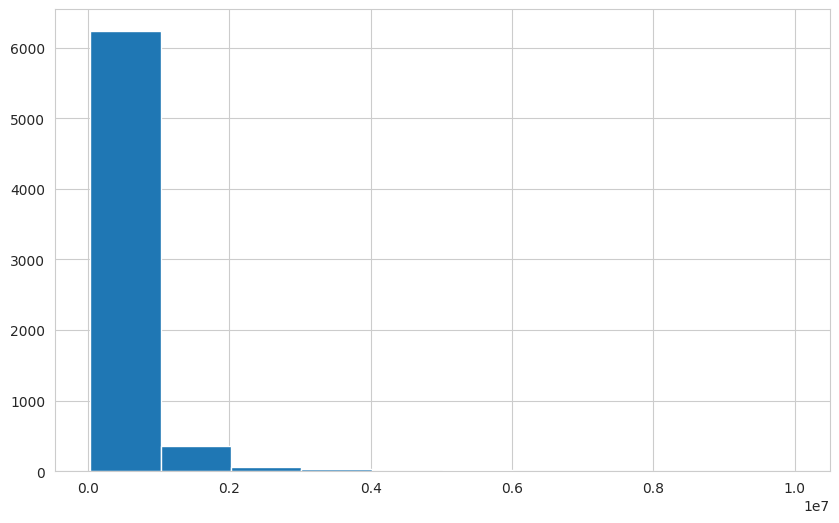

In [ ]:
# Your code here
fig, ax = plt.subplots(figsize = (10,6))
ax.hist(cars_clean['selling_price'])

plt.show()

In [ ]:
cars_clean.head(2)

In [ ]:
# Your code here

In [ ]:
# Your code here

In [ ]:
# Your code here

## Section 5a — Simple Linear Regression

*Fit a simple linear regression with your chosen predictor.*

- Define `X` and `y`
- Don't forget `sm.add_constant`
- Fit `sm.OLS(y, X).fit()`
- Print `model.summary()`
- Translate the equation into plain English (intercept + slope interpretation)


In [2]:
# Your code here
cars_clean.columns

NameError: name 'cars_clean' is not defined

In [3]:
# Your code Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'age'],
      dtype='object')here

IndentationError: unexpected indent (3610109732.py, line 2)

## Section 5b — Multi-Linear Regression Preview

*Now extend: add two more predictors and refit. Same skeleton, more columns.*

- Build a new `X` with three predictors
- Fit a new model
- Compare R² between the simple and multi-linear models
- Write the multi-LM equation in plain English — remember the "holding others constant" interpretation

> ⚠️ For Sections 6 and 7 below, **stay on the SIMPLE model** for clarity. Multi-variable inference adds complications we cover in Week 6.


In [4]:
# Your code here
cars_clean.columns

NameError: name 'cars_clean' is not defined

In [5]:
# Your codX_multi = sm.add_constant(cars_clean[['mileage', 'engine', 'max_power','km_driven','age']])

y = cars_clean['selling_price']


multi_model = sm.OLS(y, X_multi).fit()
print(multi_model.summary())e here

SyntaxError: invalid syntax (2804858575.py, line 7)

## Section 6a — Assess the Fit

*Monday's diagnostics on the simple model:*

- R²
- Residuals + residual plot (look for tube vs funnel)
- Cook's Distance (look for points with D > 1)
- Standardised residuals (flag |z| > 3)

*Write a markdown verdict — what does the fit tell you?*


In [ ]:
# Your code here

In [ ]:
# Your code here

In [ ]:
# Your code here

## Section 6b — LINE Assumptions

*Tuesday's framework. Check each letter:*

- **L** — Linearity (scatterplot with regression line)
- **I** — Independence (study-design reasoning)
- **N** — Normality of *residuals* (histogram + Q-Q plot)
- **E** — Equal variance (residual plot — funnel or tube?)

*Write a one-line verdict for each letter at the end.*


In [ ]:
# Your code here

In [ ]:
# Your code here

In [ ]:
# Your code here

## Section 6c — Slope Inference

*Pull the inference quantities from the simple model:*

- Slope (β₁)
- Standard error
- t-statistic
- p-value
- 95% CI for the slope

*Translate the numbers into plain English — what do they tell the stakeholder?*


In [ ]:
# Your code here

## Section 7a — Predictions with Uncertainty

*Pick a realistic incoming car (e.g., 82 bhp). Predict its price with both:*

- **CI** for the mean response (where does the line sit?)
- **PI** for an individual car (where might this specific car land?)

*Then build the bowtie plot — predictions across the full range of your predictor, with CI and PI bands.*


In [ ]:
# Your code here

In [ ]:
# Your code here

## Section 7b — The Report

This is the deliverable. Write for the dealership owner, not for your tutor. Plain English. Numbers should appear, but every number should be followed by an interpretation.

**Fill in each `[bracket]` below with your own words. Replace this entire markdown cell with the filled-in report when you submit.**

---

**To:** Owner, Nairobi Used Car Dealership
**From:** [Your name]
**Subject:** Pricing model recommendation
**Date:** [Today]

---

**The business question.**
*[1–2 sentences — what the owner asked you to figure out]*

**The data.**
*[2–3 sentences — what dataset you used, how much data, what cleaning you did]*

**What we found.**
*[2–3 sentences — your equation in plain English, key numbers with units, R² as a percentage. Mention both the simple and multi-LM versions if you built both.]*

**What this means for pricing.**
*[Pick a realistic example car. State the predicted price and the prediction interval as a range. This is the actionable bit.]*

**Caveats.**
*[2–3 sentences — where the model is weak, what it doesn't capture, when NOT to use it.]*

**Recommendation.**
*[How should the dealership actually use this? Be specific.]*

**Next steps.**
*[1–2 sentences — what you'd do with more time.]*

---


## Closing

You've walked the full **CRISP-DM lifecycle** on a real dataset.

The proportions tonight are pedagogical — in real life, **data preparation and stakeholder communication will dominate your week**. The technical core is often the smallest part.

That's the shape of the job.
